In [1]:
import matplotlib.pyplot as plt
import numpy as np
import arc
import pairinteraction as pi
if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=False)
import os
from IPython.display import Latex
import scipy
import pandas as pd
from pandas import DataFrame
import sys
sys.path.append(os.path.abspath("C:\\Users\\Tommy\\OneDrive - Durham University\\level 4 Project\\Code Directory\\L4-code-directory-2"))
from my_functions import *
np.set_printoptions(legacy='1.25')

h = scipy.constants.h
epsilon_0 = scipy.constants.epsilon_0
a_0 = scipy.constants.physical_constants['Bohr radius']
e = scipy.constants.e

In [2]:
colours = ('orange', 'green', 'red', 'blue')
orbs = ('s', 'p', 'd', 'f')

atom1 = 'Rb'
atom2 ='Cs'
l1_0, l2_0 = 0, 0
l1_1, l2_1 = 1, 1
j1_0, j2_0 = 1/2, 1/2


if atom1 == 'Rb':
    arc_atom1 = arc.Rubidium()
elif atom1 == 'Cs':
    arc_atom1 = arc.Caesium()
if atom2 == 'Rb':
    arc_atom2 = arc.Rubidium()
elif atom2 == 'Cs':
    arc_atom2 = arc.Caesium()
   
n_dif = 3
jdif = 3
ldif = 3
b=0
energy_unit = 'MHz'
channels = channels_import(atom1, l1_0, j1_0, atom2, l2_0, j2_0, l1_1, l2_1)

    n1_0  l1_0  j1_0  n2_0  l2_0  j2_0  n1_1  l1_1  j1_1  n2_1  ...  \
0     45     0   0.5    47     0   0.5    45     1   1.5    46  ...   
1     46     0   0.5    48     0   0.5    46     1   1.5    47  ...   
2     48     0   0.5    51     0   0.5    48     1   1.5    50  ...   
3     59     0   0.5    57     0   0.5    58     1   0.5    57  ...   
4     61     0   0.5    65     0   0.5    61     1   0.5    64  ...   
5     68     0   0.5    67     0   0.5    67     1   0.5    67  ...   
6     69     0   0.5    68     0   0.5    68     1   0.5    68  ...   
7     71     0   0.5    69     0   0.5    70     1   1.5    69  ...   
8     72     0   0.5    70     0   0.5    71     1   1.5    70  ...   
9     72     0   0.5    75     0   0.5    72     1   0.5    74  ...   
10    73     0   0.5    76     0   0.5    73     1   0.5    75  ...   
11    77     0   0.5    81     0   0.5    77     1   1.5    80  ...   
12    81     0   0.5    78     0   0.5    80     1   0.5    78  ...   
13    

In [26]:
channel = 5
c = channels.loc[channel]
# set atom properties
n1_0, l1_0, j1_0 = int(c['n1_0']), int(c['l1_0']), c['j1_0']
n2_0, l2_0, j2_0 = int(c['n2_0']), int(c['l2_0']), c['j2_0'] 

l1_1, l2_1 = int(c['l1_1']), int(c['l2_1'])

btunes = magTune_import(atom1, n1_0, l1_0, j1_0, atom2, n2_0, l2_0, j2_0, l1_1, l2_1)
b_index = 0
bmax = max(btunes)
    
theta, phi = 0, 0
dn = 3
deltamax = 1e12

n1_0, n2_0 = channels['n1_0'][channel], channels['n2_0'][channel]
n1_1, n2_1 = channels['n1_1'][channel], channels['n2_1'][channel]
j1_1, j2_1 = channels['j1_1'][channel], channels['j2_1'][channel]

defect = channels['defect'][channel]
# m1_0s, m2_0s = np.arange(-j1_0, j1_0 + 1), np.arange(-j2_0, j2_0 + 1)
# m1_i, m2_i = 0, 0


# m1_1s, m2_1s = np.arange(-j1_1, j1_1 + 1), np.arange(-j2_1, j2_1 + 1)
# m1_1i, m2_1i = 0, 0

# n1_0, n2_0 = 50, 48
# n1_1, n2_1 = 49, 48
# j1_1, j2_1 = 1/2, 1/2

# defect = 100
m1_0s, m2_0s = np.arange(-j1_0, j1_0 + 1), np.arange(-j2_0, j2_0 + 1)
m1_i, m2_i = 0, 0


m1_1s, m2_1s = np.arange(-j1_1, j1_1 + 1), np.arange(-j2_1, j2_1 + 1)
m1_1i, m2_1i = 0, 0

print(m2_1s)
# Angular plots of C6
ns = np.arange(30,110,1)

# Defining pairinteraction kets
ket1 = pi.KetAtom(atom1, n=n1_0, l=l1_0, m=m1_0s[m1_i], j=j1_0)
ket1basis = pi.BasisAtom(atom1, n=(ket1.n,ket1.n), l=(ket1.l,ket1.l), j=(ket1.j,ket1.j))

ket2 = pi.KetAtom(atom2, n=n2_0, l=l2_0, m=m2_0s[m2_i], j=j2_0)
ket2basis = pi.BasisAtom(atom2, n=(ket2.n,ket2.n), l=(ket2.l,ket2.l), j=(ket2.j,ket2.j))

ket1_energy = ket1.get_energy(unit=energy_unit)
basis1 = pi.BasisAtom(atom1, n=(ket1.n-n_dif, ket1.n+n_dif), l=(0,ket1.l+ldif), j=(1/2,ket1.j+jdif), m=(-ket1.j-jdif, ket1.j+jdif))

ket2_energy = ket2.get_energy(unit=energy_unit)
basis2 = pi.BasisAtom(atom2, n=(ket2.n-n_dif, ket2.n+n_dif), l=(0,ket2.l+ldif), j=(1/2,ket2.j+jdif), m=(-ket2.j-jdif,ket2.j+jdif))

ket1_1, ket2_1 = pi.KetAtom(atom1, n=n1_1, l=l1_1, j=j1_1, m=m1_1s[m1_1i]), pi.KetAtom(atom2, n=n2_1, l=l2_1, j=j2_1,  m=m2_1s[m2_1i])
ket1_1basis = pi.BasisAtom(atom1, n=(ket1_1.n,ket1_1.n), l=(ket1_1.l,ket1_1.l), j=(ket1_1.j,ket1_1.j))
ket2_1basis = pi.BasisAtom(atom2, n=(ket2_1.n,ket2_1.n), l=(ket2_1.l,ket2_1.l), j=(ket2_1.j,ket2_1.j))

print(ket2basis.kets)

[-1.5 -0.5  0.5  1.5]
[KetAtom(Cs:67,S_1/2,-1/2), KetAtom(Cs:67,S_1/2,1/2)]


In [30]:

maxe = .2
mine=0
num=500
electric_fields = np.linspace(mine,maxe,num)
n_dif = 3
jdif = 3
ldif = 3
b=0
energy_unit = 'MHz'
print(ket1,ket2)

|Rb:68,S_1/2,-1/2⟩ |Cs:67,S_1/2,-1/2⟩


In [31]:
from pairinteraction.visualization.colormaps import alphamagma
import os



figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\electric\\'
if not os.path.exists(figpath):
    os.makedirs(figpath)

n1=n1_0
n2=n2_0

ket1_energy = ket1.get_energy(unit=energy_unit)
# print('ket1 energy = ' + str(ket1_energy) + energy_unit)
basis1 = pi.BasisAtom(atom1, n=(ket1.n-n_dif, ket1.n+n_dif), l=(0,ket1.l+ldif), j=(1/2,ket1.j+jdif), m=(-ket1.j-jdif, ket1.j+jdif))

ket1systems = [pi.SystemAtom(ket1basis).set_magnetic_field([0, 0, b], unit='G').set_electric_field([0, 0, e], unit="V/cm") for e in electric_fields
]
pi.diagonalize(ket1systems, diagonalizer="eigen", sort_by_energy=True)
ket1energies = [system.get_eigenenergies(unit=energy_unit) - ket1_energy for system in ket1systems]

systems = [
    pi.SystemAtom(basis1).set_magnetic_field([0, 0, b], unit='G').set_electric_field([0, 0, e], unit="V/cm").set_diamagnetism_enabled(True) for e in electric_fields
]

pi.diagonalize(systems, diagonalizer="eigen", sort_by_energy=True)
eigenenergies1 = [system.get_eigenenergies(unit=energy_unit) - ket1_energy for system in systems]
overlaps1 = [system.get_eigenbasis().get_overlaps(ket1) for system in systems]

ket2_energy = ket2.get_energy(unit=energy_unit)
# print('ket2 energy = ' + str(ket2_energy) + energy_unit)

basis2 = pi.BasisAtom(atom2, n=(ket2.n-n_dif, ket2.n+n_dif), l=(0,ket2.l+2), j=(1/2,ket2.j+1), m=(-ket2.j-1,ket2.j+1))

ket2systems = [pi.SystemAtom(ket2basis).set_magnetic_field([0, 0, b], unit='G').set_electric_field([0, 0, e], unit="V/cm") for e in electric_fields
]
pi.diagonalize(ket2systems, diagonalizer="eigen", sort_by_energy=True)
ket2energies = [system.get_eigenenergies(unit=energy_unit) - ket2_energy for system in ket2systems]

systems = [
    pi.SystemAtom(basis2).set_magnetic_field([0, 0, b], unit='G').set_electric_field([0, 0, e], unit="V/cm").set_diamagnetism_enabled(True) for e in electric_fields
]

pi.diagonalize(systems, diagonalizer="eigen", sort_by_energy=True)
eigenenergies2 = [system.get_eigenenergies(unit=energy_unit) - ket2_energy for system in systems]
overlaps2 = [system.get_eigenbasis().get_overlaps(ket2) for system in systems]

# Finding defect

ket1_1 = pi.KetAtom(atom1, n=n1_1, l=l1_1, j=j1_1, m=j1_1)

ket2_1 = pi.KetAtom(atom2, n=n2_1, l=l2_1, j=j2_1, m=j2_1)
defect = ket1_1.get_energy(energy_unit) + ket2_1.get_energy(energy_unit) - ket1.get_energy(energy_unit) - ket2.get_energy(energy_unit)
print(defect)
    

2.5019571781158447


{'0.0525', '0.0361'}


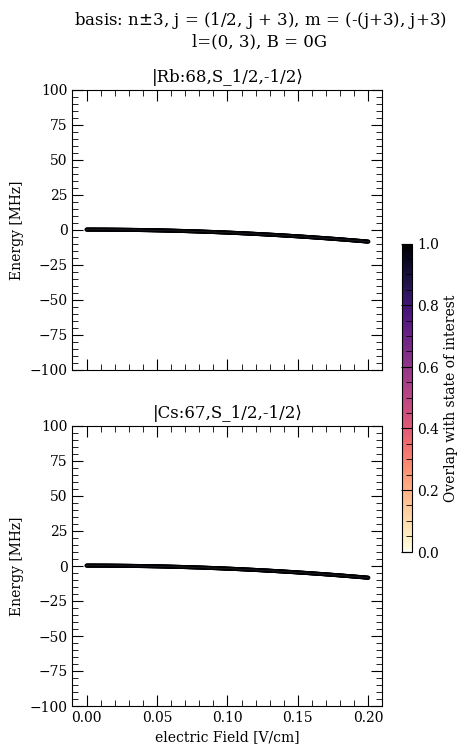

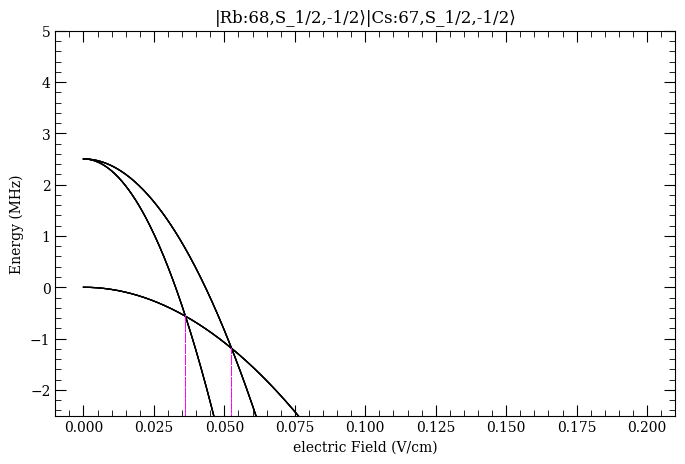

In [32]:
datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\Electric tunes\\{atom1}{atom2}\\{orbs[l1_0]}{orbs[l2_0]}\\to {orbs[l1_1]}{orbs[l2_1]}\\j1j2({j1_0},{j2_0})\\'
if not os.path.exists(datapath):
    os.makedirs(datapath)
fig, ax = plt.subplots(2,1, sharex=True, figsize=(5,8))
ylim = 100
ax[0].set_ylabel(f"Energy [{energy_unit}]")

ax[0].plot(electric_fields, np.array(eigenenergies1), c=".1", lw=0.5)

ax[0].set_title(str(ket1))
ax[0].set_ylim(-ylim,ylim)
x_repeated = np.hstack(
    [val * np.ones_like(es) for val, es in zip(electric_fields, eigenenergies1)]
)

energies_flattened1 = np.hstack(eigenenergies1)
overlaps_flattened1 = np.hstack(overlaps1)
sorter1 = np.argsort(overlaps_flattened1)

scat = ax[0].scatter(
    x_repeated[sorter1],
    energies_flattened1[sorter1],
    c=overlaps_flattened1[sorter1],
    s=15,
    vmin=0,
    vmax=1,
    cmap=alphamagma,
    marker='.'
)
fig.colorbar(scat, ax=ax, label="Overlap with state of interest", aspect=30, shrink=.5)

ax[1].set_ylabel(f"Energy [{energy_unit}]")

ax[1].plot(electric_fields, np.array(eigenenergies2), c=".1", lw=0.5)
ax[1].set_title(str(ket2))
ax[1].set_ylim(-ylim,ylim)
x_repeated = np.hstack(
    [val * np.ones_like(es) for val, es in zip(electric_fields, eigenenergies2)]
)

energies_flattened2 = np.hstack(eigenenergies2)
overlaps_flattened2 = np.hstack(overlaps2)
sorter2 = np.argsort(overlaps_flattened2)

scat = ax[1].scatter(
    x_repeated[sorter2],
    energies_flattened2[sorter2],
    c=overlaps_flattened2[sorter2],
    s=15,
    vmin=0,
    vmax=1,
    cmap=alphamagma,
    marker='.'
)
plt.xlabel("electric Field [V/cm]")
plt.suptitle(fr'basis: n$\pm${n_dif}, j = (1/2, j + {jdif}), m = (-(j+{jdif}), j+{jdif})' '\n' f'l=(0, {ldif}), B = {b}G')

fig = plt.figure(figsize = (8,5))
energy_lim = abs(defect + defect/2)
offset=defect/2
min_energy = -energy_lim+offset
max_energy = energy_lim+offset
eigenenergies_pair = []
state0s = []

for i, channel1 in enumerate(np.transpose(eigenenergies1)):
    for j, channel2 in enumerate(np.transpose(eigenenergies2)):
        eigenenergy = channel1 + channel2
        if abs(ket1_1.get_energy(energy_unit)-ket1_energy) - 2 <= abs(channel1[0]) <= abs(ket1_1.get_energy(energy_unit)-ket1_energy)+2 and abs(ket2_1.get_energy(energy_unit)-ket2_energy)-2 <= abs(channel2[0]) <= abs(ket2_1.get_energy(energy_unit)-ket2_energy)+2 or  -2 <= abs(channel1[0]) <= +2 and -2 <= abs(channel2[0]) <= +2:
            plt.plot(electric_fields, eigenenergy, c="0", lw=0.9)
            

            eigenenergies_pair.append(eigenenergy)
            if  eigenenergy[0] == 0:
                state0s.append(eigenenergy)
                # print(state0[-1])

plt.title(f'{str(ket1)}{str(ket2)}')
plt.ylim(min_energy, max_energy)
plt.ylabel(f"Energy ({energy_unit})")
plt.xlabel("electric Field (V/cm)")

tunes=[]
for eigenenergy in eigenenergies_pair:
    if eigenenergy[0] == state0s[0][0]:
        continue
    elif round(defect, 3)-.5 <= round(eigenenergy[0],2) <= round(defect, 3)+.5:

        for state0 in state0s:
            
            energy = eigenenergy-state0
            cross = min(energy, key=abs)
            if abs(cross) < 1:
                index = list(energy).index(cross)
                if index == 0 or index == len(electric_fields)-1:
                    continue
                else:
                    tuned = electric_fields[index]
                    plt.vlines(x=tuned, ymin = min_energy, ymax = eigenenergy[index], linestyles='dashed', colors='magenta', linewidth = 0.5)
                    tunes.append(format(round(tuned, 4), ".15g"))

# plt.axhline(defect, color='r', linewidth=2, alpha=1, linestyle='dotted')
print(set(tunes))

tunes = pd.DataFrame({'tunes' : tunes})

tunes.to_csv(datapath + f'{n1_0}{n2_0}.csv')

# fig.savefig(figpath + f'\\es  ({mine, maxe})G.png')


In [33]:
n_dif=3
ldif=3
jdif=3
def get_system_pair_list_b(
    ket1: pi.SystemAtom, ket2: pi.SystemAtom, b_fields: np.ndarray, d, erange
) -> list[pi.SystemPair]:
    
    basis1 = pi.BasisAtom(atom1, n=(ket1.n-n_dif, ket1.n+n_dif), l=(0,ket1.l+ldif), j=(1/2,ket1.j+jdif), m=(-ket1.j-jdif, ket1.j+jdif))

    basis2 = pi.BasisAtom(atom2, n=(ket2.n-n_dif, ket2.n+n_dif), l=(0,ket2.l+ldif), j=(1/2,ket2.j+jdif), m=(-ket2.j-jdif, ket2.j+jdif))

    pair_systems = []
    for i, e in enumerate(b_fields):
        system1, system2 = pi.SystemAtom(basis1).set_electric_field([0,0,e], unit='V/cm'), pi.SystemAtom(basis2).set_electric_field([0,0,e], unit='V/cm')

        if i == 0:
            pair_energy = ket1.get_energy(unit=energy_unit) + ket2.get_energy(unit=energy_unit)

        pi.diagonalize([system1, system2])
        # print(f'pair energy = {pair_energy}{energy_unit}')
        min_energy, max_energy = pair_energy - erange, pair_energy + erange
        
        pair_basis = pi.BasisPair(
            [system1, system2], energy=(min_energy, max_energy), energy_unit=energy_unit
        )
        pair_systems.append(
            pi.SystemPair(pair_basis)
            .set_distance(d, unit='um')
            )
        states_num = pair_basis.number_of_states
        # print(f"Number of two-atom basis states: {pair_basis.number_of_states}")


    # Diagonalize the systems in parallel
    pi.diagonalize(
        pair_systems,
        diagonalizer="eigen",
        energy_range=(min_energy, max_energy),
        energy_range_unit=energy_unit,
    )

    return pair_systems, states_num


In [34]:
magnetic_fields_nums = enumerate(electric_fields)
nums_b_fields_sub = list(magnetic_fields_nums)[::2]
b_fields_sub = list(electric_fields)[::2]
r = [300]
ket1, ket2 = pi.KetAtom(atom1, n=n1, l=l1_0, j=j1_0, m=j1_0), pi.KetAtom(atom2, n=n2, l=l2_0, j=j2_0, m=j2_0)

bfield = 0  # Gauss
erange = abs(defect + defect*2000)
system_pairs_dict: dict[float, list[pi.SystemPair]] = {}
for d in r:
    pairs = get_system_pair_list_b(ket1, ket2, b_fields_sub, d, erange)
    system_pairs_dict[d] = pairs[0]
    states_num = pairs[1]


print(system_pairs_dict)

{300: [SystemPair(BasisPair(|Rb:65,S_1/2,-1/2; Cs:70,S_1/2,-1/2⟩ ... |Rb:70,D_5/2,5/2; Cs:64,S_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:65,S_1/2,-1/2; ~Cs:70,S_1/2,-1/2⟩ ... |~Rb:70,D_5/2,1/2; ~Cs:64,S_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:65,S_1/2,-1/2; ~Cs:70,S_1/2,-1/2⟩ ... |~Rb:70,D_5/2,1/2; ~Cs:64,S_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:65,S_1/2,-1/2; ~Cs:70,S_1/2,-1/2⟩ ... |~Rb:70,D_5/2,1/2; ~Cs:64,S_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:65,S_1/2,-1/2; ~Cs:70,S_1/2,-1/2⟩ ... |~Rb:70,D_5/2,1/2; ~Cs:64,S_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:65,S_1/2,-1/2; ~Cs:70,S_1/2,-1/2⟩ ... |~Rb:70,D_5/2,1/2; ~Cs:64,S_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:65,S_1/2,-1/2; ~Cs:70,S_1/2,-1/2⟩ ... |~Rb:70,D_5/2,1/2; ~Cs:64,S_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(|~Rb:65,S_1/2,-1/2; ~Cs:70,S_1/2,-1/2⟩ ... |~Rb:70,D_5/2,1/2; ~Cs:64,S_1/2,1/2⟩), is_diagonal=True), SystemPair(BasisPair(

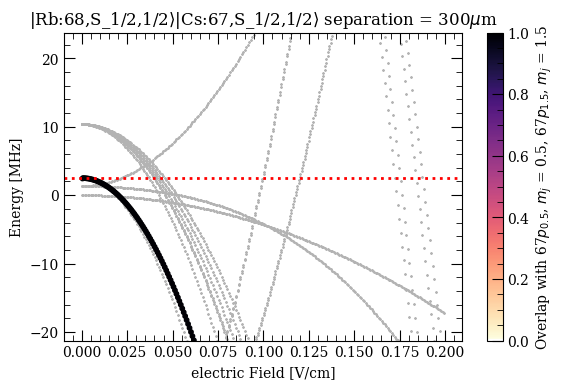

In [35]:


for i, d in enumerate(r):
    fig, ax = plt.subplots(ncols=1, figsize=(6, 4))
    ax.set_xlabel("E_z (mV/cm)")
    ax.set_ylabel(f"Energy ({energy_unit})")
    ax.set_title(fr'separation {d} $\mu$m')
    # ax.set_ylim(-0.01, 0.01)

    # system_atom = system_atom_dict[efield]
    pair_energy = ket1_energy + ket2_energy
    system_pairs = system_pairs_dict[d]
    ket1_1 = pi.KetAtom(atom1, n=n1_1, l=l1_1, j=j1_1, m=j1_1)

    ket2_1 = pi.KetAtom(atom2, n=n2_1, l=l2_1, j=j2_1, m=j2_1)

    energies = [system.get_eigenenergies(unit = energy_unit) - pair_energy for system in system_pairs]    
    overlaps = [system.get_eigenbasis().get_overlaps([ket1_1, ket2_1]) for system in system_pairs]

    # ax.plot(e_fields_sub, energies)
    for x, es in zip(b_fields_sub, energies):
        plt.plot([x] * len(es), es, c='.7', ls="None", marker=".", ms=1, zorder=-1)



    # for x, es in zip(e_fields_sub, energies_0):
    #     ax[1].plot([x] * len(es), es, c='.1', ls="None", marker=".", ms=2, zorder=-10)
    
    # print(energies[0])
    # print(energies_0[0])
    # potential = []
    # for es1, es0 in zip(energies, energies_0):
    #     es = []
    #     es1, es0 = list(es1), list(es0)
    #     try:
    #         max1 = np.max(es1)
    #         max0 = np.max(es0)
    #         min1 = np.min(es1)
    #         min0 = np.min(es0)
    #         emax = max1 - max0
    #         emin = min1 - min0

    #         potential.append([emin,emax, emin+emax])
    #     except(ValueError):
    #         continue
    
    # for x, es in zip(e_fields_sub, potential):
    #     ax[1].plot([x] * len(es), es, c='.1', ls="None", marker=".", ms=2, zorder=-10)
    plt.axhline(defect, color='r', linewidth=2, alpha=1, linestyle='dotted')

    plt.tight_layout()
  
    plt.title(fr'{str(ket1)}{str(ket2)} separation = {d}$\mu$m')
    energy_lim = abs(defect + defect*8)
    offset=defect/2
    min_energy = -energy_lim+offset
    max_energy = energy_lim+offset
    plt.ylim(min_energy, max_energy)
    # plt.xlim(2, 2.7)
    plt.ylabel(f"Energy [{energy_unit}]")
    plt.xlabel("electric Field [V/cm]")
    # 
    tunes=[]
    # for eigenenergy in energies:
    #     if eigenenergy[0] == state0s[0][0]:
    #         # ax.plot(electric_fields, eigenenergy, c='blue', lw=0.3, linestyle = 'dashed')
    #         continue
    #     elif round(abs(defect), 4) <= round(abs(eigenenergy[0]),4) <= round(abs(defect), 4):
    #         # ax.plot(electric_fields, eigenenergy, c='blue', lw=0.3, linestyle = 'dashed')
    #         for state0 in state0s:
                
    #             energy = eigenenergy-state0
    #             cross = min(energy, key=abs)
    #             if abs(cross) < 1:
    #                 index = list(energy).index(cross)
    #                 if index == 0 or index == len(magnetic_fields)-1:
    #                     continue
    #                 else:
    #                     tuned = magnetic_fields[index]
    #                     # ax.vlines(x=tuned, ymin = min_energy, ymax = eigenenergy[index], linestyles='dashed', colors='magenta', linewidth = 0.5)
    #                     tunes.append(format(round(tuned, 4), ".15g"))
    min_overlap = 0.000
    for x, es, os in zip(b_fields_sub, energies, overlaps):
        inds = np.argwhere(os > min_overlap).flatten()
        inds = inds[np.argsort(os[inds])]
        if len(inds) > 0:
            scat = plt.scatter(
                [x] * len(es[inds]),
                es[inds],
                c=os[inds],
                s=10,
                vmin=0,
                vmax=1,
                cmap=alphamagma,
            )
    fig.colorbar(scat, ax=ax, label=fr"Overlap with {ket1_1.n}${orbs[int(ket1_1.l)]}_{{{ket1_1.j}}}$, $m_j$ = {ket1_1.m}, {ket2_1.n}${orbs[int(ket2_1.l)]}_{{{ket2_1.j}}}$, $m_j$ = {ket2_1.m}")
    # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
    plt.show()
    # fig.savefig(path + f'level pairstate sep{r}.png')